In [272]:
# =========================================================
# 1. IMPORTS & CONFIG
# =========================================================

import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

In [273]:
# =========================================================
# 2. LOAD MASTER DATASET
# =========================================================

DATA_PATH = "../data/gold/master_hourly_dataset.parquet"

df = pd.read_parquet(DATA_PATH)

print(df.shape)

df.head(30)

(140256, 42)


,Temperatura,Temperatura màxima,Temperatura mínima,Humitat relativa,Humitat relativa màxima,Humitat relativa mínima,Pressió atmosfèrica,Pressió atmosfèrica mínima,Velocitat del vent a 6 m (esc.),Ratxa màxima del vent a 6 m,Precipitació,Precipitació màxima en 1 minut,Irradiància solar global,wind_u,wind_v,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,month,hour,is_operational_hour,wind_data_available,valid_wind_observation,operational_gap
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,11.800000,12.1,11.3,48.0,49.0,46.0,989.5,989.0,7.40,16.900000,0.2,0.2,0.0,-1.852812e+00,-7.164292,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0
2010-01-01 01:00:00,10.900000,11.3,10.3,49.0,51.0,47.0,990.0,989.0,7.80,17.200001,0.0,0.0,0.0,-6.119811e-01,-7.775955,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0
2010-01-01 02:00:00,10.300000,10.3,10.2,49.5,51.0,48.0,990.0,989.0,7.95,15.900000,0.0,0.0,0.0,-2.081055e-01,-7.947276,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,0,0,0,0
2010-01-01 03:00:00,9.850000,10.2,9.6,47.0,48.0,47.0,990.5,990.0,8.00,16.299999,0.0,0.0,0.0,-6.276729e-01,-7.975338,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,0,0,0,0
2010-01-01 04:00:00,9.500000,9.6,9.4,46.0,47.0,45.0,991.0,990.0,7.15,15.900000,0.0,0.0,0.0,-1.241584e+00,-7.041375,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4,0,0,0,0
2010-01-01 05:00:00,9.500000,9.5,9.4,43.5,46.0,42.0,992.0,991.0,7.15,15.600000,0.0,0.0,0.0,-1.547544e+00,-6.980516,14.0,14.0,2.62,2.49,6.65,6.00,7.68,8.63,212.0,214.0,23.0,14.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,5,0,0,0,0
2010-01-01 06:00:00,9.450000,9.6,9.3,42.0,43.0,42.0,993.0,992.0,9.00,17.700001,0.0,0.0,0.0,-1.794310e+00,-8.819323,13.9,13.9,2.44,2.29,6.91,6.04,8.32,9.05,213.0,208.0,18.0,13.983333,NaN,-0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,6,0,0,0,0
2010-01-01 07:00:00,9.299999,9.5,9.2,43.0,43.0,42.0,993.5,992.0,7.65,15.600000,0.0,0.0,53.0,-4.670223e-01,-7.635731,14.0,14.0,2.06,1.95,6.50,5.70,8.32,8.03,216.0,220.0,24.0,13.983333,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,7,1,0,0,1
2010-01-01 08:00:00,9.850000,10.4,9.4,41.5,43.0,40.0,994.0,993.0,7.75,16.600000,0.0,0.0,305.0,5.406134e-01,-7.731121,13.9,13.9,2.36,2.28,7.32,6.23,8.66,8.28,216.0,216.0,17.0,13.966667,NaN,-0.1,NaN,10.750000,269.5,10.000000,3.0,22.0,1.000000,1,8,1,1,1,0


In [274]:
# =========================================================
# 3. TEMPORAL FEATURES
# =========================================================

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# -------------------------
# Basic temporal features
# -------------------------

df['hour'] = df.index.hour
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month

# -------------------------
# Seasonal encoding
# -------------------------

# Meteorological seasons
df['season'] = (
    (df['month'] % 12 + 3) // 3
)

# 1=winter, 2=spring, 3=summer, 4=autumn

# -------------------------
# Cyclical encoding
# -------------------------

# Hour cycle
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Annual cycle
df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

print("Temporal features created.")

Temporal features created.


In [275]:
df.columns

Index(['Temperatura', 'Temperatura màxima', 'Temperatura mínima',
       'Humitat relativa', 'Humitat relativa màxima',
       'Humitat relativa mínima', 'Pressió atmosfèrica',
       'Pressió atmosfèrica mínima', 'Velocitat del vent a 6 m (esc.)',
       'Ratxa màxima del vent a 6 m', 'Precipitació',
       'Precipitació màxima en 1 minut', 'Irradiància solar global', 'wind_u',
       'wind_v', 'sst', 'sst_original', 'wave_height', 'wave_height_h13',
       'wave_period_mean', 'wave_period_tm02', 'wave_peak_period',
       'wave_max_period', 'wave_direction', 'wave_peak_direction',
       'wave_angular_spread', 'sst_roll_6h', 'sst_roll_24h', 'sst_delta_3h',
       'sst_delta_24h', 'temperature', 'wind_direction_deg', 'wind_avg',
       'wind_min', 'wind_max', 'unknown', 'month', 'hour',
       'is_operational_hour', 'wind_data_available', 'valid_wind_observation',
       'operational_gap', 'day_of_year', 'season', 'hour_sin', 'hour_cos',
       'doy_sin', 'doy_cos'],
      dtype='str'

In [276]:
df[['Temperatura', 'temperature']].describe()

,Temperatura,temperature
count,140063.000000,72947.000000
mean,17.132998,19.449976
std,5.997047,5.996816
min,-0.600000,0.000000
25%,12.500000,14.500000
50%,16.799999,19.000000
75%,22.250000,25.000000
max,37.150002,34.000000


In [277]:
(df['Temperatura'] - df['temperature']).describe()

count    72855.000000
mean        -0.934905
std          1.846535
min         -8.650002
25%         -2.150000
50%         -1.000000
75%          0.250000
max         12.950001
dtype: float64

In [278]:
# -------------------------
# Pressure tendency
# -------------------------

df['pressure_tendency_3h'] = (
    df['Pressió atmosfèrica'] -
    df['Pressió atmosfèrica'].shift(3)
)

df['pressure_tendency_6h'] = (
    df['Pressió atmosfèrica'] -
    df['Pressió atmosfèrica'].shift(6)
)

In [279]:
# -------------------------
# Combined air temperature
# -------------------------

df['air_temp_combined'] = (
    df[['Temperatura', 'temperature']]
    .mean(axis=1)
)

In [280]:
# -------------------------
# Coastal vs inland temperature difference
# -------------------------

df['coastal_inland_temp_diff'] = (
    df['Temperatura'] - df['temperature']
)

In [281]:
# -------------------------
# Land-Sea Thermal Gradient
# -------------------------

df['land_sea_temp_gradient'] = (
    df['air_temp_combined'] - df['sst']
)

In [282]:
df['land_sea_temp_gradient'].describe()

count    139193.000000
mean         -1.513958
std           3.073949
min         -15.050000
25%          -3.300000
50%          -1.075000
75%           0.650002
max          11.599999
Name: land_sea_temp_gradient, dtype: float64

<Axes: >

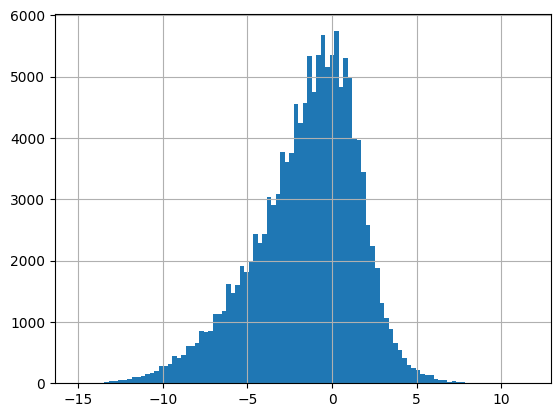

In [283]:
df['land_sea_temp_gradient'].hist(bins=100)

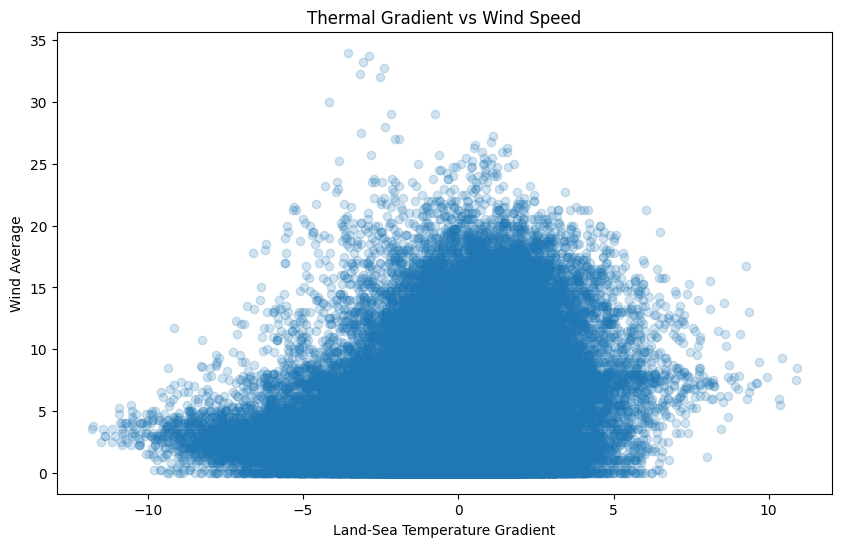

In [284]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['land_sea_temp_gradient'],
    df['wind_avg'],
    alpha=0.2
)

plt.xlabel('Land-Sea Temperature Gradient')
plt.ylabel('Wind Average')
plt.title('Thermal Gradient vs Wind Speed')

plt.show()

In [285]:
df.groupby('hour')[
    'land_sea_temp_gradient'
].mean()

hour
0    -2.659483
1    -2.914790
2    -3.163647
3    -3.403617
4    -3.606105
5    -3.634901
6    -3.279598
7    -2.425748
8    -1.589610
9    -1.265582
10   -0.925836
11   -0.581151
12   -0.258949
13    0.047013
14    0.268527
15    0.353031
16    0.271296
17    0.084933
18   -0.120823
19   -0.537771
20   -0.883685
21   -1.584256
22   -2.144048
23   -2.395579
Name: land_sea_temp_gradient, dtype: float64

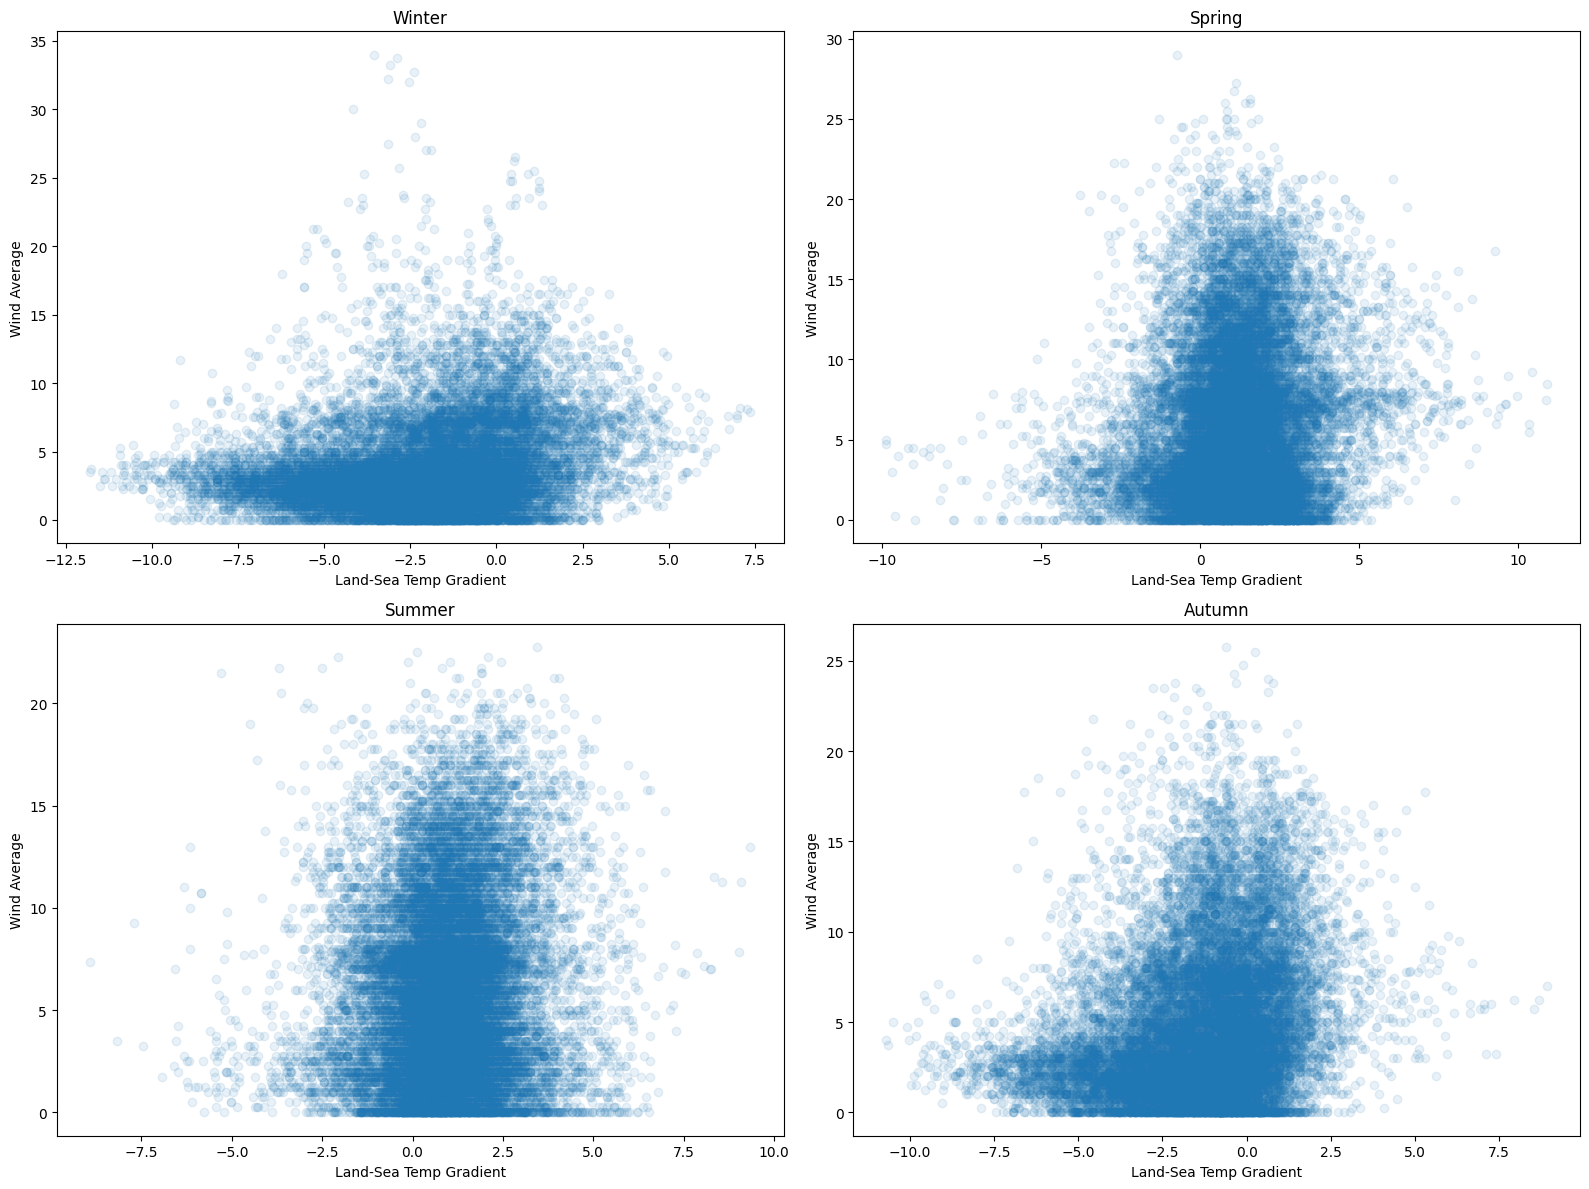

In [286]:
import matplotlib.pyplot as plt

seasons = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Autumn'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes = axes.flatten()

for season_num, ax in zip(seasons.keys(), axes):

    subset = df[df['season'] == season_num]

    ax.scatter(
        subset['land_sea_temp_gradient'],
        subset['wind_avg'],
        alpha=0.1
    )

    ax.set_title(seasons[season_num])
    ax.set_xlabel('Land-Sea Temp Gradient')
    ax.set_ylabel('Wind Average')

plt.tight_layout()
plt.show()

In [287]:
# =========================================================
# THERMAL WIND FLAG
# =========================================================

df['thermal_wind_flag'] = (
    (df['wind_avg'] > 10) &
    (df['wind_max'] > 15) &
    (
        (df['wind_direction_deg'] >= 110) &
        (df['wind_direction_deg'] <= 220)
    )
)

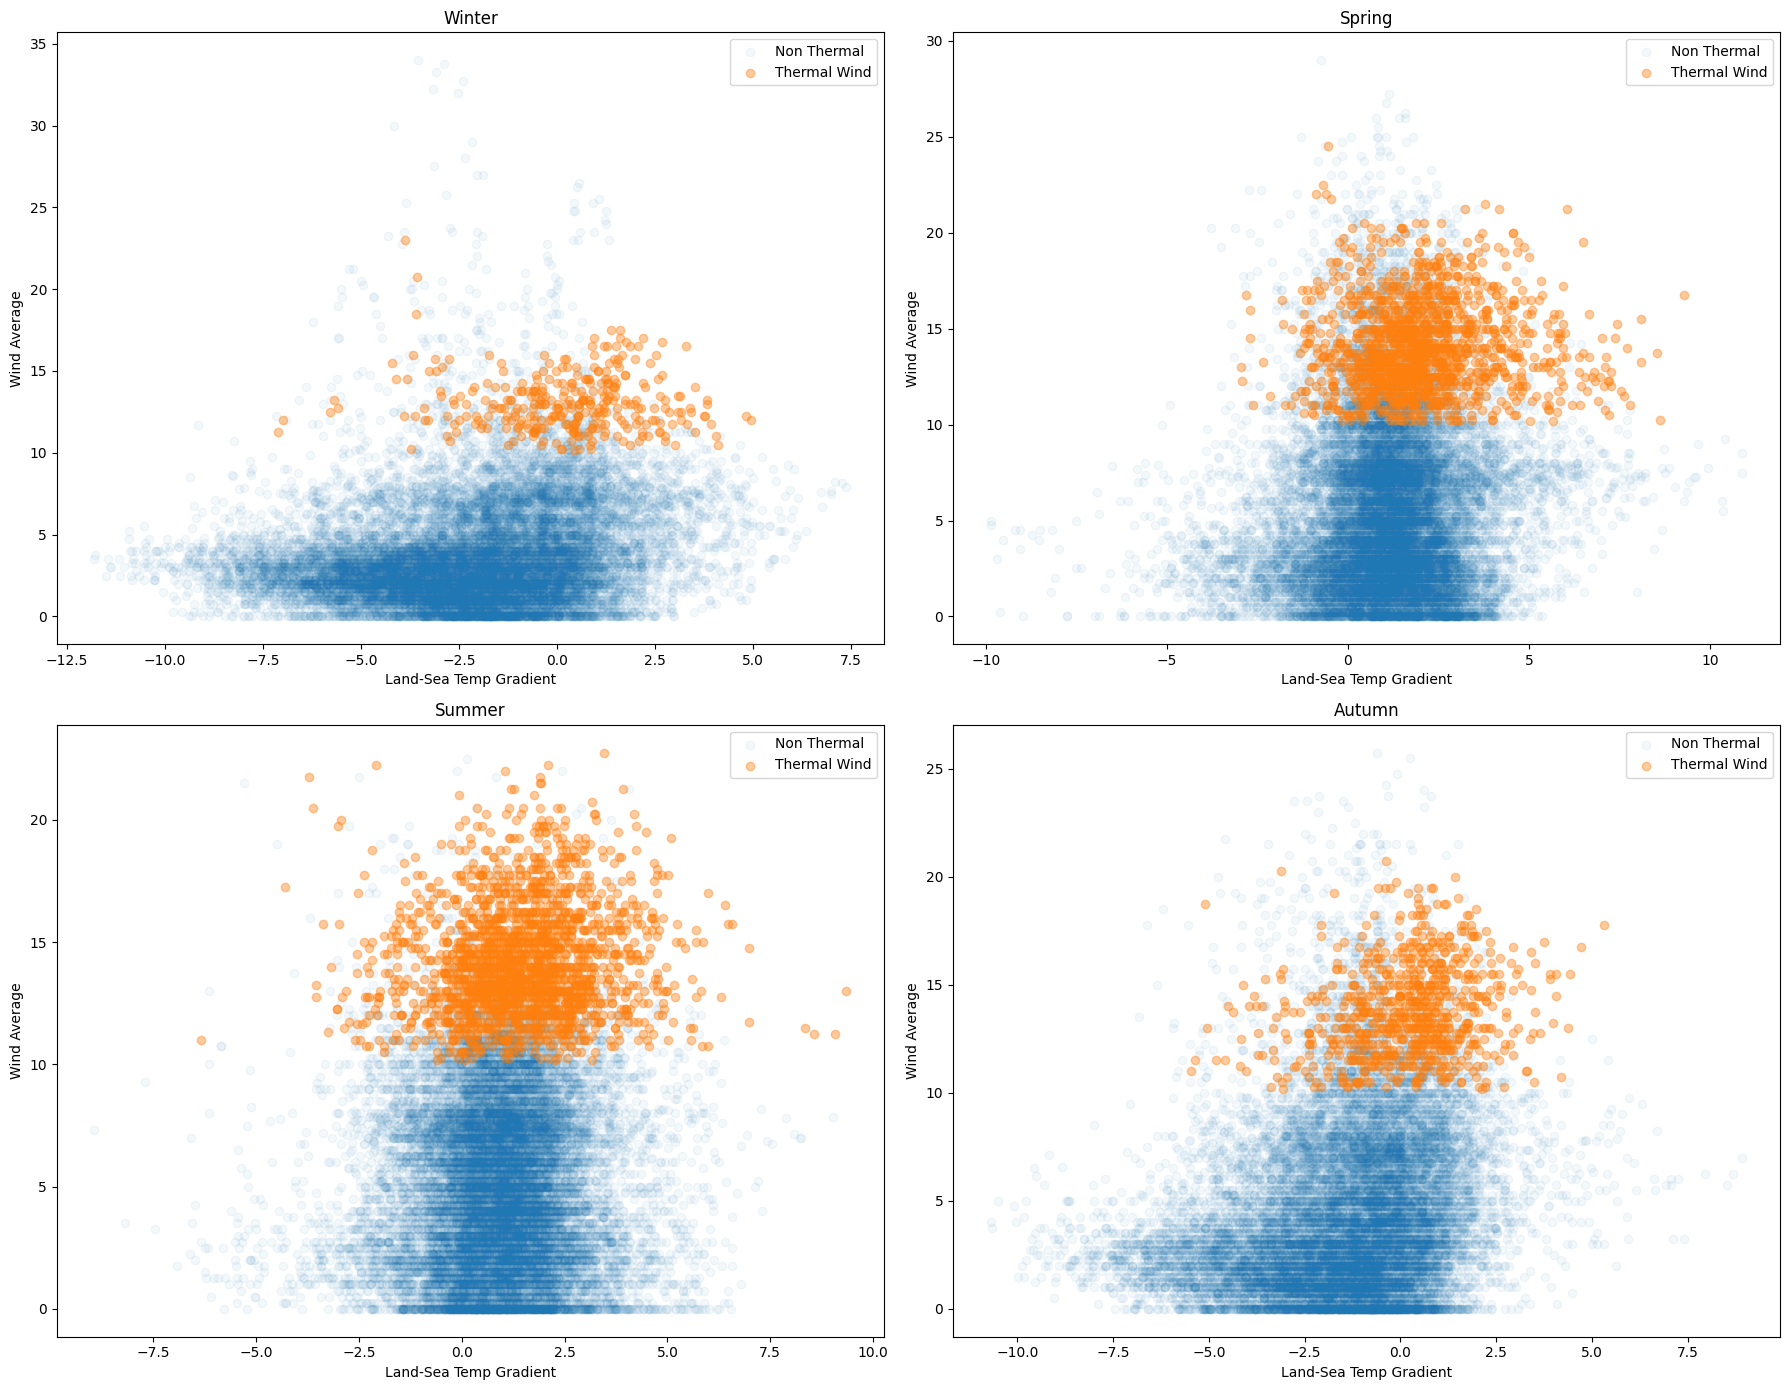

In [288]:
import matplotlib.pyplot as plt

seasons = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Autumn'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

axes = axes.flatten()

for season_num, ax in zip(seasons.keys(), axes):

    subset = df[df['season'] == season_num]

    # Non thermal
    non_thermal = subset[~subset['thermal_wind_flag']]

    ax.scatter(
        non_thermal['land_sea_temp_gradient'],
        non_thermal['wind_avg'],
        alpha=0.05,
        label='Non Thermal'
    )

    # Thermal
    thermal = subset[subset['thermal_wind_flag']]

    ax.scatter(
        thermal['land_sea_temp_gradient'],
        thermal['wind_avg'],
        alpha=0.4,
        label='Thermal Wind'
    )

    ax.set_title(seasons[season_num])

    ax.set_xlabel('Land-Sea Temp Gradient')
    ax.set_ylabel('Wind Average')

    ax.legend()

plt.tight_layout()

plt.show()

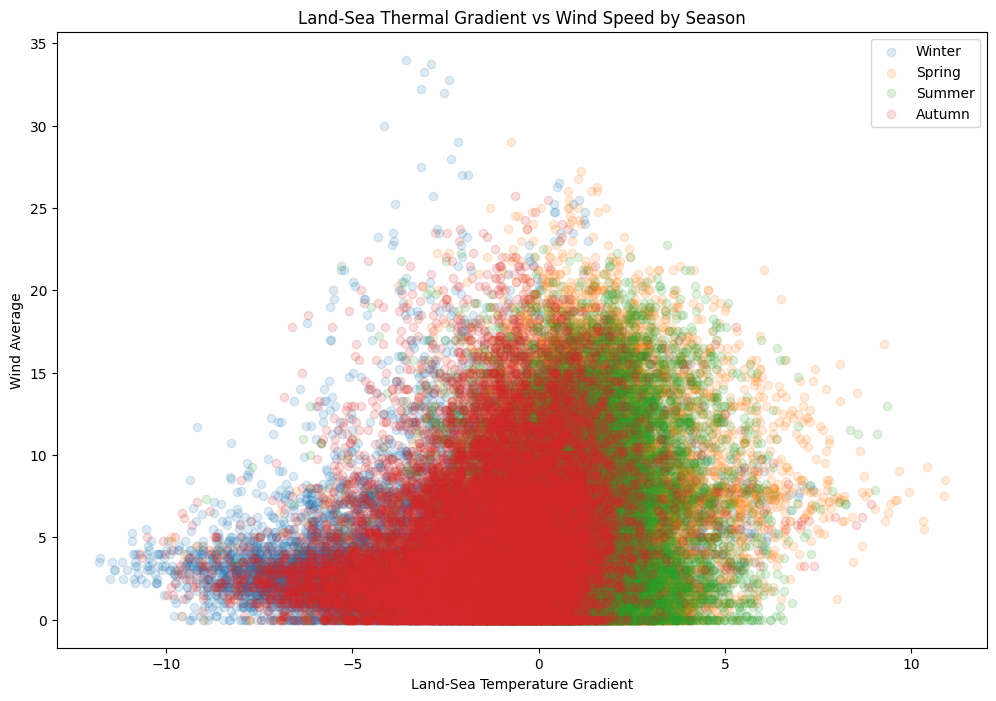

In [289]:
import matplotlib.pyplot as plt

season_names = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Autumn'
}

plt.figure(figsize=(12, 8))

for season_num, season_name in season_names.items():

    subset = df[df['season'] == season_num]

    plt.scatter(
        subset['land_sea_temp_gradient'],
        subset['wind_avg'],
        alpha=0.15,
        label=season_name
    )

plt.xlabel('Land-Sea Temperature Gradient')
plt.ylabel('Wind Average')
plt.title('Land-Sea Thermal Gradient vs Wind Speed by Season')

plt.legend()

plt.show()

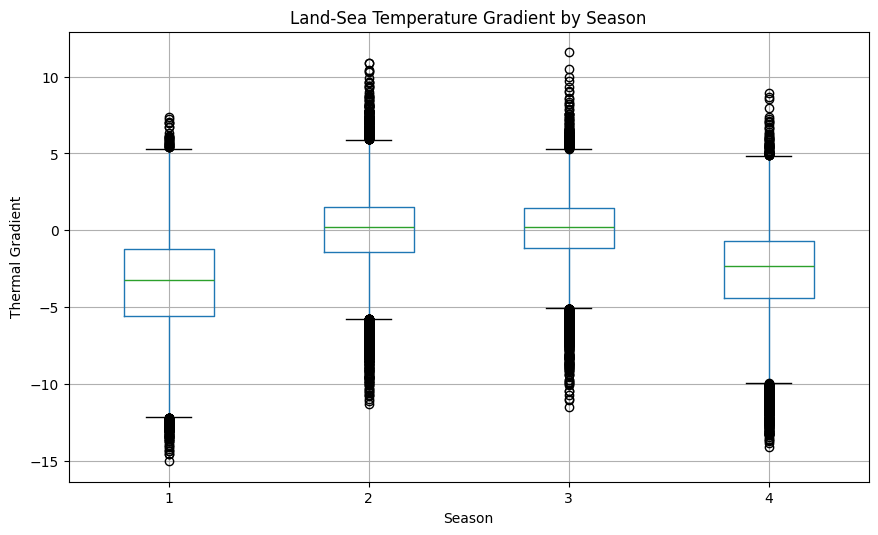

In [290]:
import matplotlib.pyplot as plt

df.boxplot(
    column='land_sea_temp_gradient',
    by='season',
    figsize=(10,6)
)

plt.title('Land-Sea Temperature Gradient by Season')
plt.suptitle('')
plt.xlabel('Season')
plt.ylabel('Thermal Gradient')

plt.show()

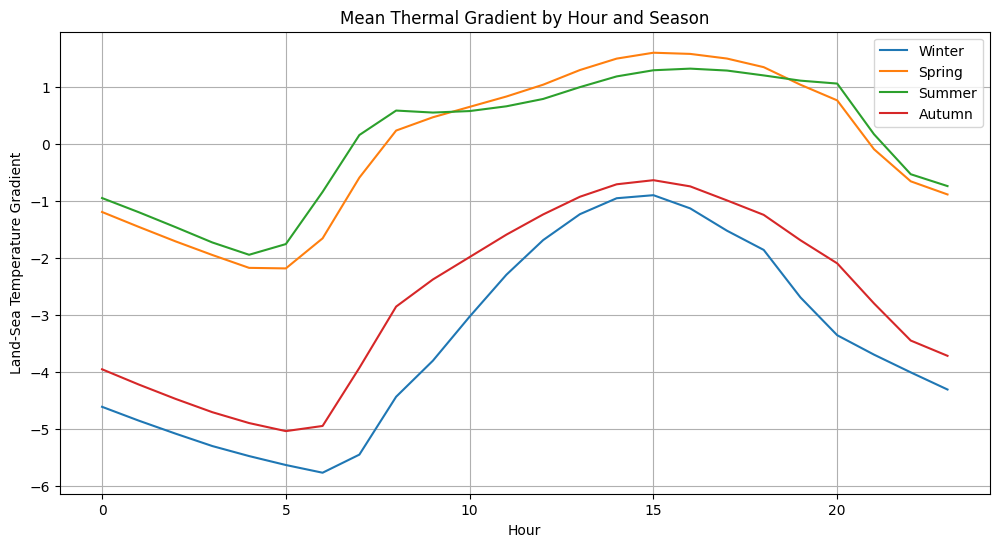

In [291]:
hourly = (
    df.groupby(['season', 'hour'])
      ['land_sea_temp_gradient']
      .mean()
      .unstack(0)
)

hourly.columns = ['Winter', 'Spring', 'Summer', 'Autumn']

hourly.plot(
    figsize=(12,6)
)

plt.title('Mean Thermal Gradient by Hour and Season')
plt.xlabel('Hour')
plt.ylabel('Land-Sea Temperature Gradient')

plt.grid(True)

plt.show()

### 1. Heatmap de viento medio

Objetivo:

¿Cuándo sopla más viento?

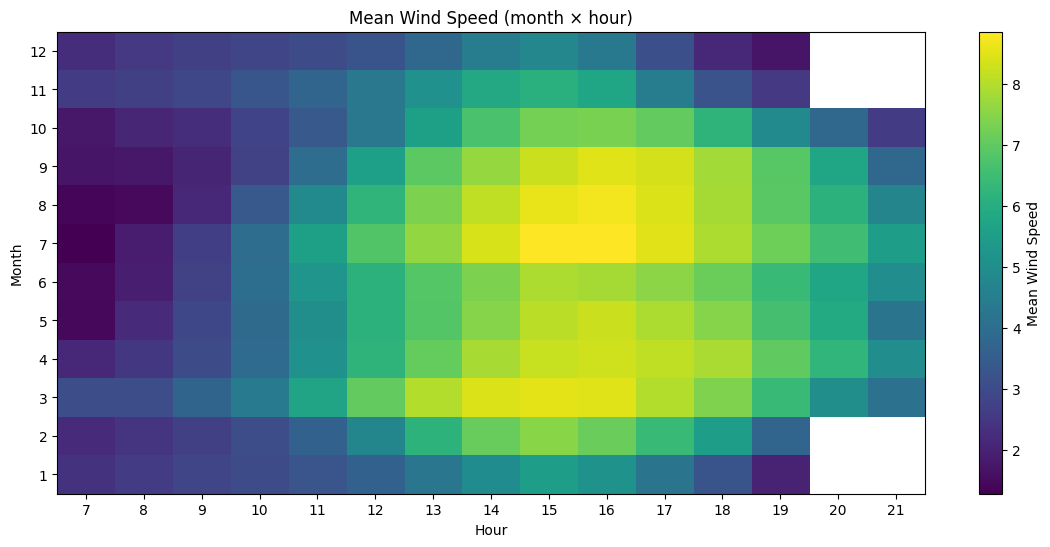

In [292]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap_wind = pd.pivot_table(
    df,
    values='wind_avg',
    index='month',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

plt.imshow(
    heatmap_wind,
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='Mean Wind Speed')

plt.xlabel('Hour')
plt.ylabel('Month')

plt.title('Mean Wind Speed (month × hour)')

plt.xticks(
    range(len(heatmap_wind.columns)),
    heatmap_wind.columns
)
plt.yticks(range(12), range(1,13))

plt.show()

### 2. Heatmap del gradiente térmico

Objetivo:

¿Cuándo existe realmente el motor térmico?

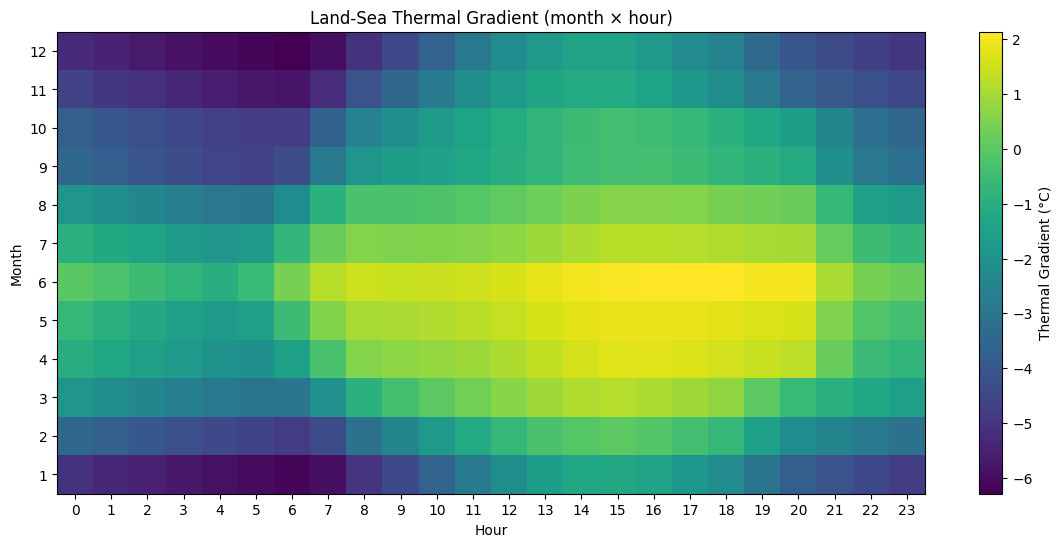

In [293]:
heatmap_gradient = pd.pivot_table(
    df,
    values='land_sea_temp_gradient',
    index='month',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

plt.imshow(
    heatmap_gradient,
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='Thermal Gradient (°C)')

plt.xlabel('Hour')
plt.ylabel('Month')

plt.title('Land-Sea Thermal Gradient (month × hour)')

plt.xticks(range(24))
plt.yticks(range(12), range(1,13))

plt.show()

### 3. Heatmap de frecuencia de viento térmico

Este es probablemente el más interesante.

In [294]:
df['thermal_event'] = (
    (df['wind_avg'] > 10)
    & (df['wind_max'] > 15)
    & (df['wind_direction_deg'].between(110,220))
).astype(int)

In [295]:
heatmap_thermal = pd.pivot_table(
    df,
    values='thermal_event',
    index='month',
    columns='hour',
    aggfunc='mean'
) * 100

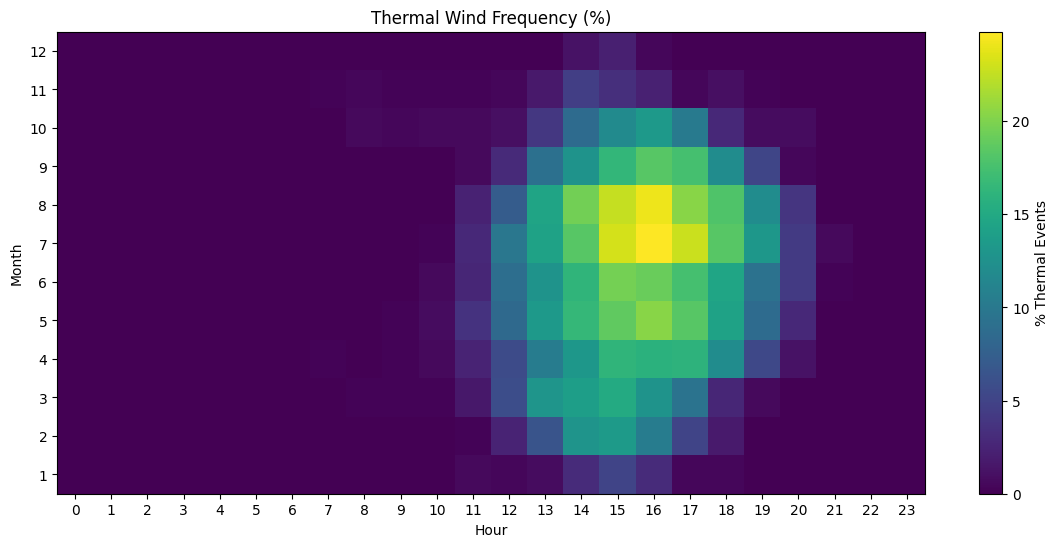

In [296]:
plt.figure(figsize=(14,6))

plt.imshow(
    heatmap_thermal,
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='% Thermal Events')

plt.xlabel('Hour')
plt.ylabel('Month')

plt.title('Thermal Wind Frequency (%)')

plt.xticks(range(24))
plt.yticks(range(12), range(1,13))

plt.show()

### 1. Frecuencia de viento navegable (>10 knots)

In [297]:
# =========================================================
# SAILABLE WIND
# =========================================================

df['sailable_wind'] = (
    df['wind_avg'] > 10
).astype(int)

#### Heatmap (% de veces que hay viento navegable)

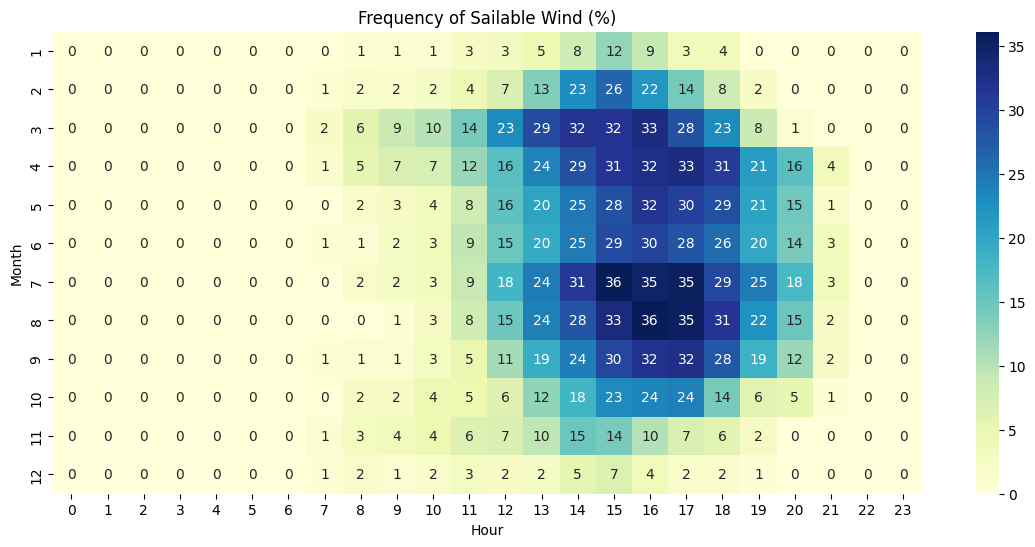

In [298]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_sailable = pd.pivot_table(
    df,
    values='sailable_wind',
    index='month',
    columns='hour',
    aggfunc='mean'
) * 100

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_sailable,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title('Frequency of Sailable Wind (%)')
plt.xlabel('Hour')
plt.ylabel('Month')

plt.show()

Durante julio-agosto, aproximadamente 1 de cada 3 observaciones tiene viento navegable.

#### 2. Frecuencia de Thermal Event

Usando la definición actual:

* wind_avg > 10 kt
* wind_max > 15 kt
* dirección térmica

In [299]:
# =========================================================
# THERMAL EVENT
# =========================================================

df['thermal_event'] = (
    (df['wind_avg'] > 10)
    &
    (df['wind_max'] > 15)
    &
    (
        (df['wind_direction_deg'] >= 110)
        &
        (df['wind_direction_deg'] <= 220)
    )
).astype(int)

#### Heatmap (% de eventos térmicos)

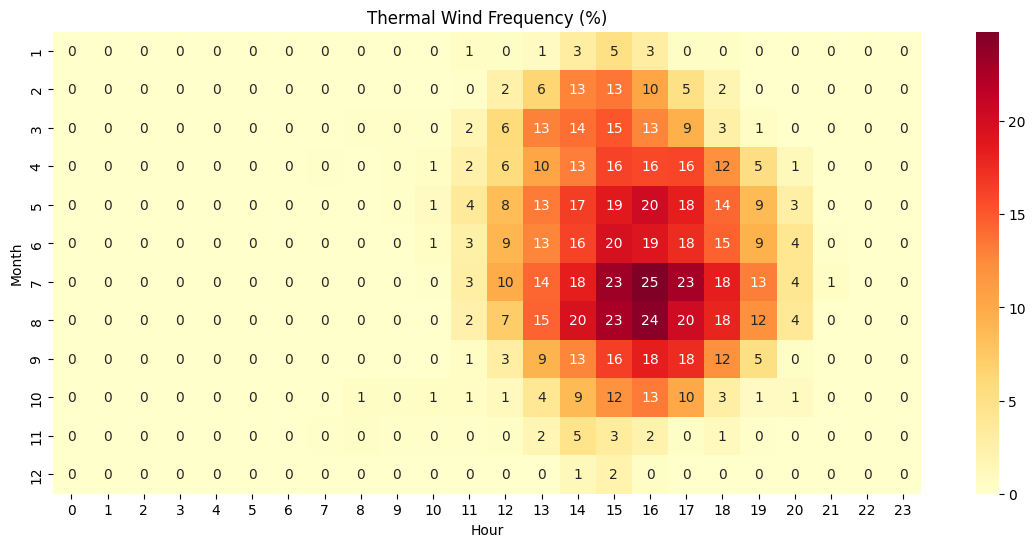

In [300]:
heatmap_thermal = pd.pivot_table(
    df,
    values='thermal_event',
    index='month',
    columns='hour',
    aggfunc='mean'
) * 100

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_thermal,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f'
)

plt.title('Thermal Wind Frequency (%)')
plt.xlabel('Hour')
plt.ylabel('Month')

plt.show()

Aquí aparece el fenómeno que realmente queremos modelar.

Máximo absoluto:
Julio
15h-16h

Frecuencia: 
25%

Esto significa algo muy interesante:

NO todos los vientos navegables son térmicos.

#### 3. Heatmap diferencial (muy recomendable)

In [301]:
heatmap_difference = (
    heatmap_thermal -
    heatmap_sailable
)

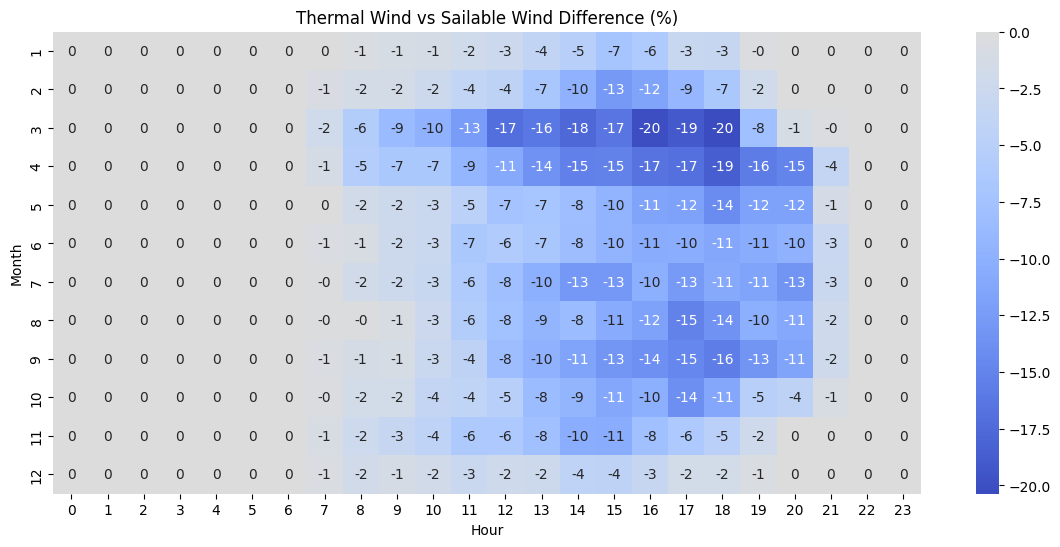

In [302]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_difference,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.0f'
)

plt.title('Thermal Wind vs Sailable Wind Difference (%)')
plt.xlabel('Hour')
plt.ylabel('Month')

plt.show()

Todos los valores son negativos.

¿Por qué?

thermal_event ⊂ sailable_wind

Todo thermal_event es navegable.

Pero no todo viento navegable es térmico.
Marzo
Abril
Septiembre
Octubre

Las diferencias son enormes:
-15%
-20%

Interpretación:

Hay muchos días con:
wind_avg > 10 kt

pero que NO cumplen:

* dirección térmica
* patrón térmico

Eso sugiere que en esas estaciones domina más:

sinóptico
mistral
levante
frentes

y menos Sea Breeze puro.






#### Frecuencia por mes

In [303]:
monthly_sailable = (
    df.groupby('month')['sailable_wind']
      .mean()
      * 100
)

monthly_thermal = (
    df.groupby('month')['thermal_event']
      .mean()
      * 100
)

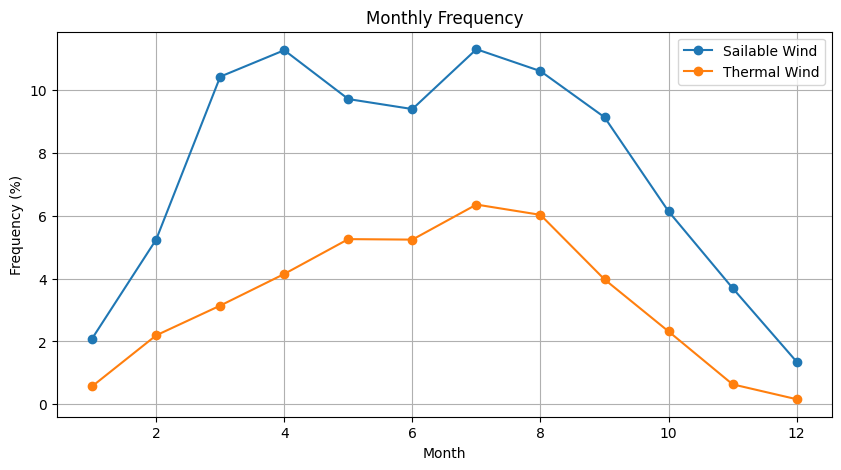

In [304]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sailable.index,
         monthly_sailable.values,
         marker='o',
         label='Sailable Wind')

plt.plot(monthly_thermal.index,
         monthly_thermal.values,
         marker='o',
         label='Thermal Wind')

plt.legend()

plt.xlabel('Month')
plt.ylabel('Frequency (%)')

plt.title('Monthly Frequency')

plt.grid()

plt.show()

### ¿Dónde empieza y dónde termina realmente la temporada térmica?

# 4. Physical Metrics Analysis

### BLOQUE 1: CORRELACIONES

¿Qué variables están realmente relacionadas con el viento térmico?

In [305]:
corr_cols = [
    'wind_avg',
    'thermal_event',
    'land_sea_temp_gradient',
    'air_temp_combined',
    'sst',
    'Irradiància solar global',
    'Pressió atmosfèrica',
    'Humitat relativa'
]

#### Pearson

Relaciones lineales.

In [306]:
pearson_corr = df[corr_cols].corr(method='pearson')

pearson_corr

,wind_avg,thermal_event,land_sea_temp_gradient,air_temp_combined,sst,Irradiància solar global,Pressió atmosfèrica,Humitat relativa
wind_avg,1.000000,0.519927,0.248082,0.166392,0.069083,-0.047762,-0.145875,0.023664
thermal_event,0.519927,1.000000,0.173191,0.145201,0.073676,0.119752,-0.046691,-0.058705
land_sea_temp_gradient,0.248082,0.173191,1.000000,0.632991,0.164669,0.368866,-0.104808,-0.026041
air_temp_combined,0.166392,0.145201,0.632991,1.000000,0.867825,0.326007,-0.097439,0.091652
sst,0.069083,0.073676,0.164669,0.867825,1.000000,0.178419,-0.059022,0.134087
Irradiància solar global,-0.047762,0.119752,0.368866,0.326007,0.178419,1.000000,0.012247,-0.192116
Pressió atmosfèrica,-0.145875,-0.046691,-0.104808,-0.097439,-0.059022,0.012247,1.000000,-0.010113
Humitat relativa,0.023664,-0.058705,-0.026041,0.091652,0.134087,-0.192116,-0.010113,1.000000


#### Spearman

In [307]:
spearman_corr = df[corr_cols].corr(method='spearman')

spearman_corr

,wind_avg,thermal_event,land_sea_temp_gradient,air_temp_combined,sst,Irradiància solar global,Pressió atmosfèrica,Humitat relativa
wind_avg,1.000000,0.399521,0.253494,0.179394,0.069121,-0.035659,-0.170599,0.014441
thermal_event,0.399521,1.000000,0.189134,0.144766,0.071583,0.143598,-0.058904,-0.066911
land_sea_temp_gradient,0.253494,0.189134,1.000000,0.603820,0.156338,0.379149,-0.121053,-0.032231
air_temp_combined,0.179394,0.144766,0.603820,1.000000,0.859376,0.299869,-0.137985,0.080612
sst,0.069121,0.071583,0.156338,0.859376,1.000000,0.151953,-0.094452,0.119032
Irradiància solar global,-0.035659,0.143598,0.379149,0.299869,0.151953,1.000000,-0.022971,-0.201400
Pressió atmosfèrica,-0.170599,-0.058904,-0.121053,-0.137985,-0.094452,-0.022971,1.000000,-0.028763
Humitat relativa,0.014441,-0.066911,-0.032231,0.080612,0.119032,-0.201400,-0.028763,1.000000


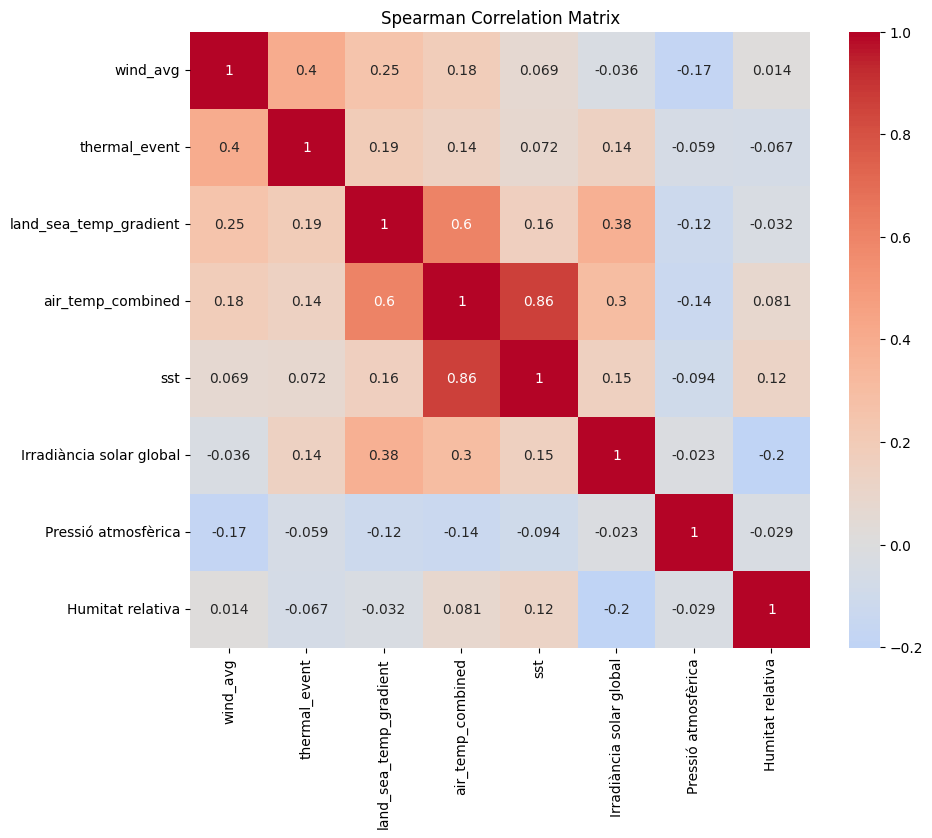

In [308]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Spearman Correlation Matrix')

plt.show()

### BLOQUE 2: Variables explicativas

Aquí veremos si las variables realmente separan los eventos térmicos.

#### Gradiente térmico

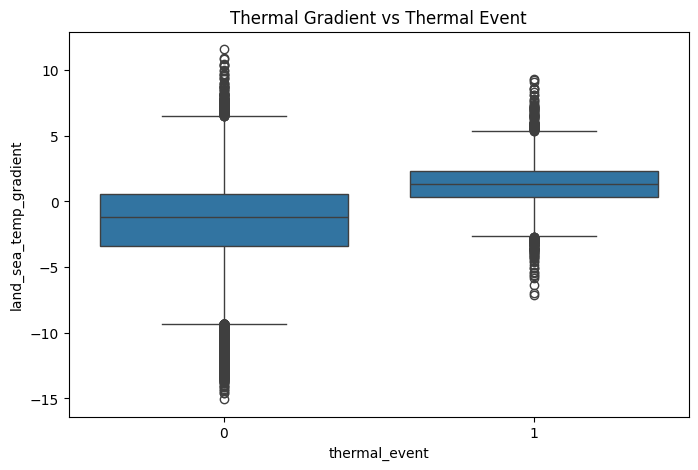

In [309]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='thermal_event',
    y='land_sea_temp_gradient'
)

plt.title('Thermal Gradient vs Thermal Event')

plt.show()

#### Irradiancia

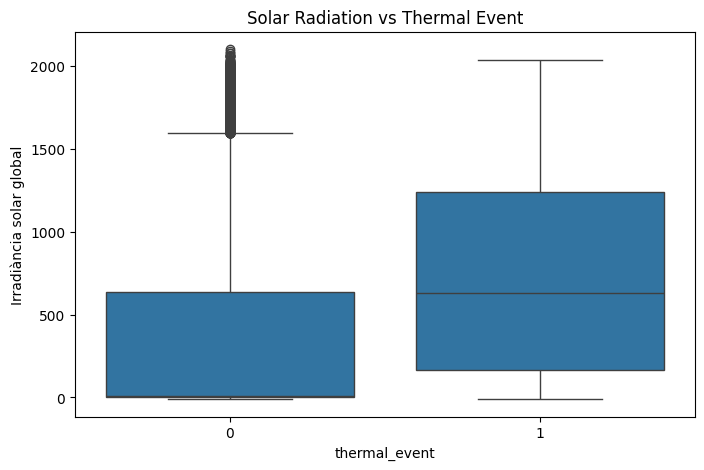

In [310]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='thermal_event',
    y='Irradiància solar global'
)

plt.title('Solar Radiation vs Thermal Event')

plt.show()

#### SST

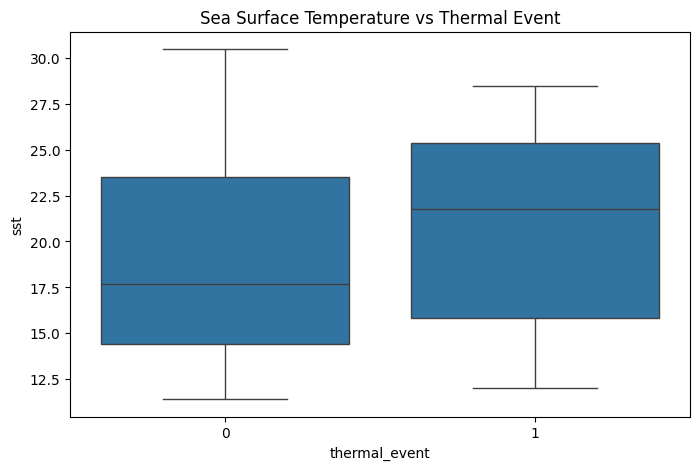

In [311]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='thermal_event',
    y='sst'
)

plt.title('Sea Surface Temperature vs Thermal Event')

plt.show()

### BLOQUE 3: Nuevas métricas físicas

#### 1. Daily Temperature Range

In [312]:
# =========================================================
# DAILY TEMPERATURE RANGE
# =========================================================

daily_tmax = (
    df['air_temp_combined']
    .groupby(df.index.date)
    .transform('max')
)

daily_tmin = (
    df['air_temp_combined']
    .groupby(df.index.date)
    .transform('min')
)

df['daily_temp_range'] = (
    daily_tmax - daily_tmin
)

print(
    df['daily_temp_range']
    .describe()
)

count    140256.000000
mean          5.262513
std           1.670546
min           0.774999
25%           4.100000
50%           5.150002
75%           6.374998
max          11.549998
Name: daily_temp_range, dtype: float64


In [313]:
sample_day = '2024-07-15'

df.loc[sample_day, [
    'air_temp_combined',
    'daily_temp_range'
]].head(24)

,air_temp_combined,daily_temp_range
datetime,,
2024-07-15 00:00:00,24.150002,3.700001
2024-07-15 01:00:00,24.200001,3.700001
2024-07-15 02:00:00,23.799999,3.700001
2024-07-15 03:00:00,23.350000,3.700001
2024-07-15 04:00:00,23.049999,3.700001
2024-07-15 05:00:00,23.700001,3.700001
2024-07-15 06:00:00,24.700001,3.700001
2024-07-15 07:00:00,25.325000,3.700001
2024-07-15 08:00:00,25.525000,3.700001


#### ¿Los días con gran amplitud térmica generan más Sea Breeze?

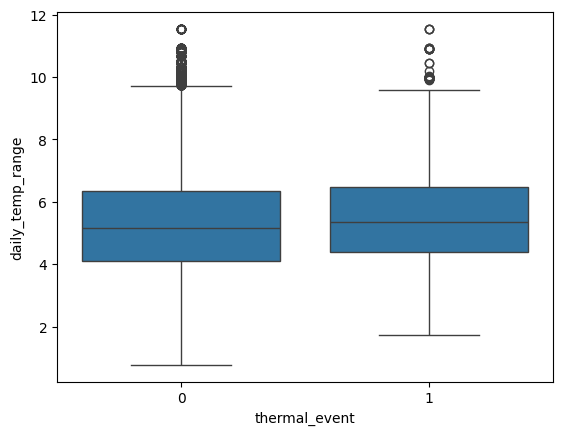

In [314]:
sns.boxplot(
    data=df,
    x='thermal_event',
    y='daily_temp_range'
);

#### 2. Solar Energy Accumulation

La energía acumulada suele ser más importante que la irradiancia instantánea.

In [315]:
df['solar_roll_3h'] = (
    df['Irradiància solar global']
    .rolling(3)
    .mean()
)

df['solar_roll_6h'] = (
    df['Irradiància solar global']
    .rolling(6)
    .mean()
)

#### ¿Cuánta energía solar acumulada necesita el sistema antes de generar térmico?

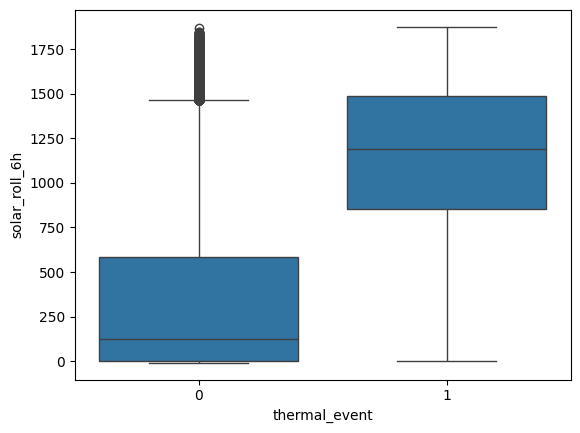

In [316]:
sns.boxplot(
    data=df,
    x='thermal_event',
    y='solar_roll_6h'
);

#### 3. SST Anomaly

para detectar días excepcionalmente favorables

In [317]:
df['sst_climatology'] = (
    df['sst']
    .rolling(24*30, min_periods=24)
    .mean()
)

df['sst_anomaly'] = (
    df['sst']
    -
    df['sst_climatology']
)

#### ¿El térmico aparece más cuando el mar está más frío o más cálido de lo normal?

<Axes: xlabel='thermal_event', ylabel='sst_anomaly'>

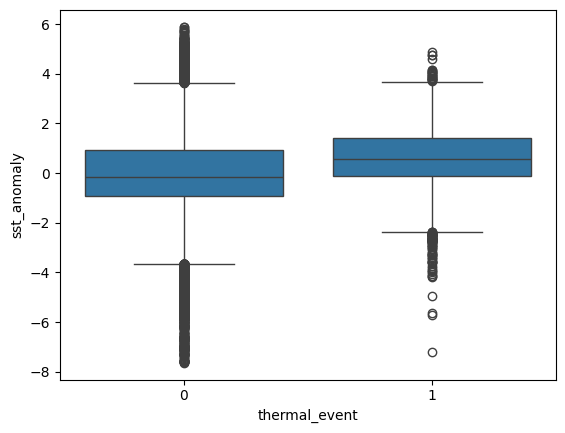

In [318]:
sns.boxplot(
    data=df,
    x='thermal_event',
    y='sst_anomaly'
)

### Gradiente térmico

Agrupar por bins:

### Cuando el gradiente aumenta

¿cómo aumenta la probabilidad de térmico?

In [319]:
df['gradient_bin'] = pd.cut(
    df['land_sea_temp_gradient'],
    bins=20
)

In [320]:
thermal_probability = (
    df.groupby('gradient_bin')['thermal_event']
      .mean()
      * 100
)

<Axes: xlabel='gradient_bin'>

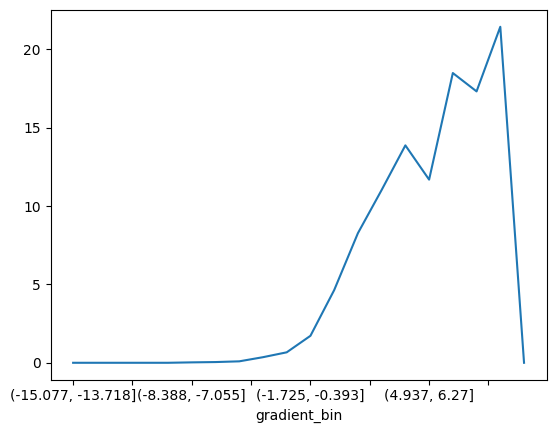

In [321]:
thermal_probability.plot()

=========================================================

THERMAL EVENT PROBABILITY VS SOLAR RADIATION

=========================================================

Pregunta física

¿Aumenta la probabilidad de Sea Breeze cuando aumenta la irradiancia solar?

Hipótesis

Más radiación solar →
Más calentamiento de la tierra →
Mayor gradiente tierra-mar →
Mayor probabilidad de viento térmico.

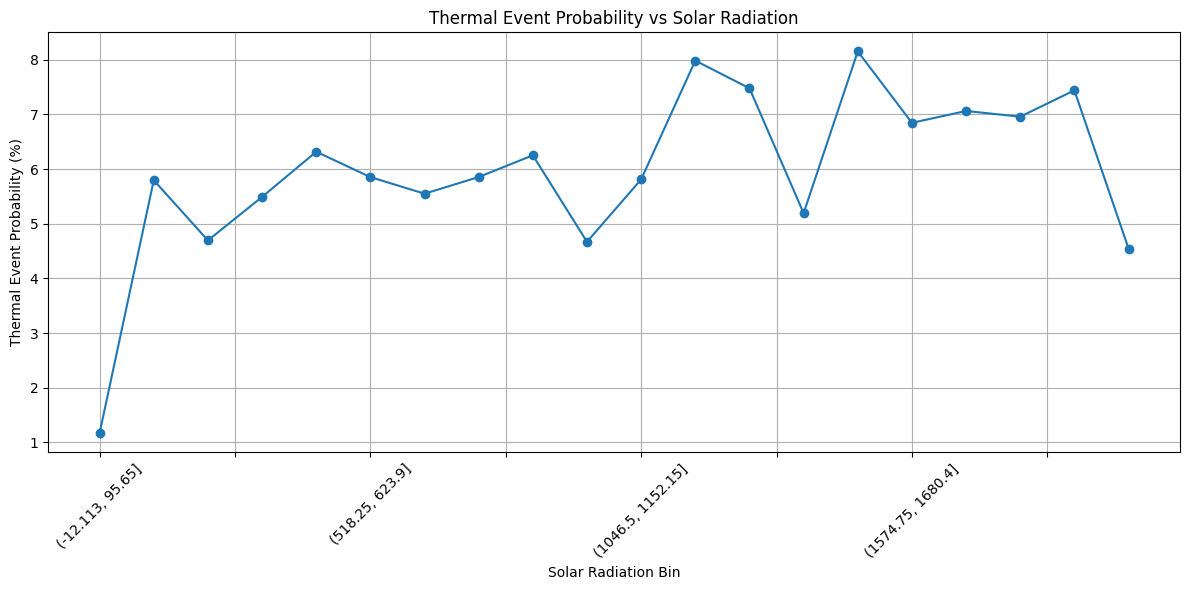

In [322]:
import pandas as pd
import matplotlib.pyplot as plt

# Create irradiance bins

df['irradiance_bin'] = pd.cut(
    df['Irradiància solar global'],
    bins=20
)

# Thermal probability by irradiance bin

thermal_prob_irradiance = (
    df.groupby('irradiance_bin', observed=False)['thermal_event']
      .mean()
      * 100
)

# Plot

plt.figure(figsize=(12,6))

thermal_prob_irradiance.plot(
    marker='o'
)

plt.title(
    'Thermal Event Probability vs Solar Radiation'
)

plt.xlabel('Solar Radiation Bin')

plt.ylabel('Thermal Event Probability (%)')

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

=========================================================

THERMAL EVENT PROBABILITY VS SEA SURFACE TEMPERATURE

=========================================================

Pregunta física

¿Existe una SST óptima para la formación del Sea Breeze?

Hipótesis

La SST influye en el contraste térmico tierra-mar.

Una SST demasiado fría o demasiado cálida podría reducir la intensidad del gradiente térmico.

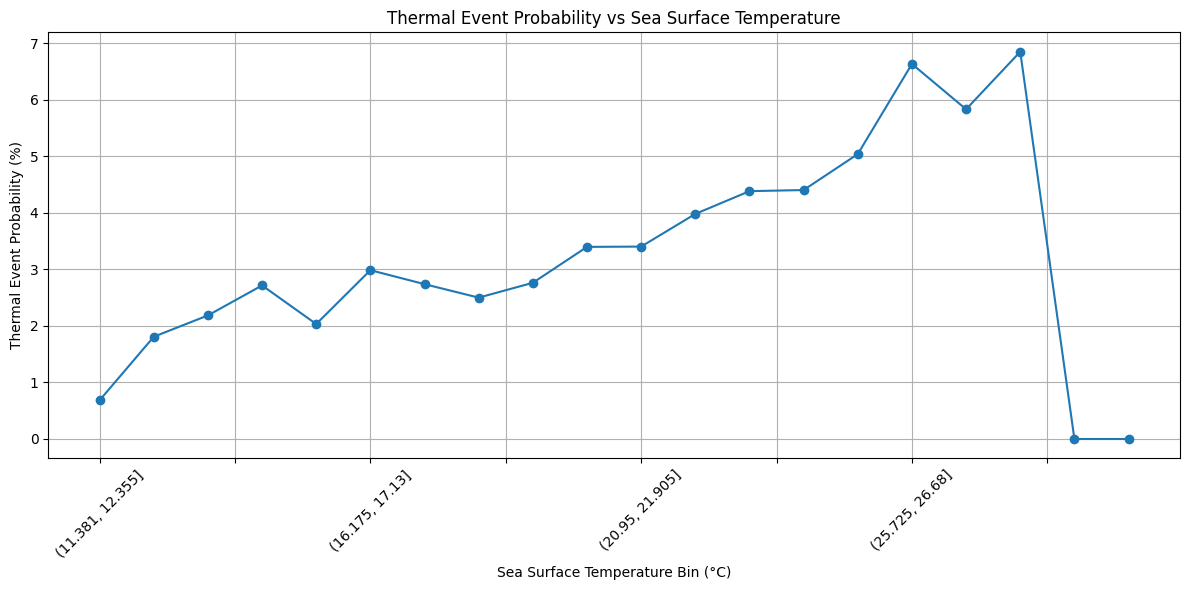

In [323]:
import pandas as pd
import matplotlib.pyplot as plt

# Create SST bins

df['sst_bin'] = pd.cut(
    df['sst'],
    bins=20
)

# Thermal probability by SST bin

thermal_prob_sst = (
    df.groupby('sst_bin', observed=False)['thermal_event']
      .mean()
      * 100
)

# Plot

plt.figure(figsize=(12,6))

thermal_prob_sst.plot(
    marker='o'
)

plt.title(
    'Thermal Event Probability vs Sea Surface Temperature'
)

plt.xlabel('Sea Surface Temperature Bin (°C)')

plt.ylabel('Thermal Event Probability (%)')

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [324]:
df['solar_gradient_interaction'] = (
    df['land_sea_temp_gradient']
    *
    df['Irradiància solar global']
)

In [325]:
df['sst_air_diff'] = (
    df['air_temp_combined']
    - df['sst']
)

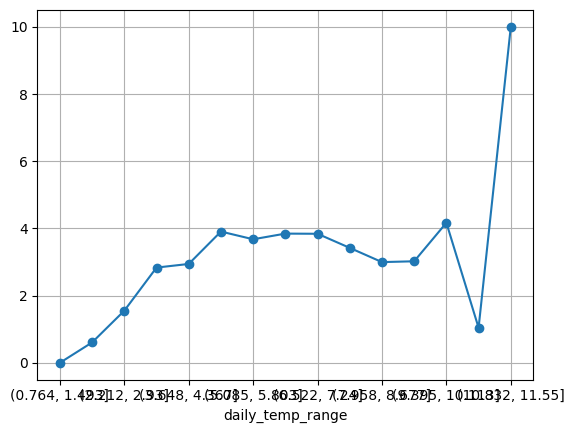

In [326]:
daily_range_prob = (
    df.groupby(
        pd.cut(df['daily_temp_range'], bins=15)
    )['thermal_event']
    .mean()
    * 100
)

daily_range_prob.plot(marker='o')
plt.grid(True)
plt.show()

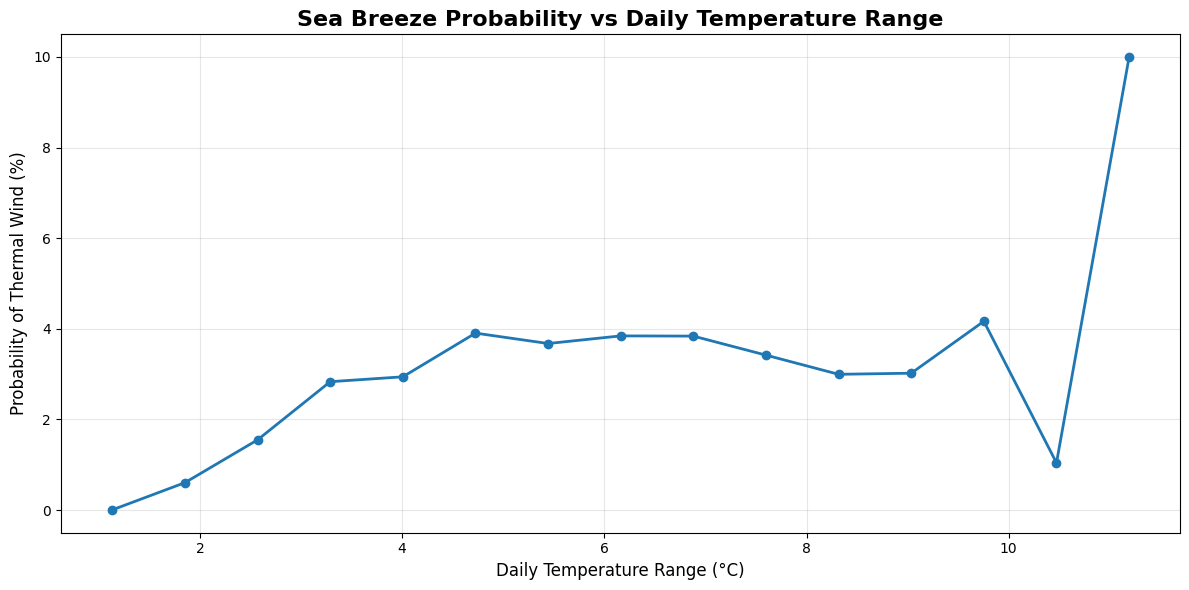

In [327]:
# =========================================================
# THERMAL EVENT PROBABILITY VS DAILY TEMPERATURE RANGE
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create bins
df['daily_range_bin'] = pd.cut(
    df['daily_temp_range'],
    bins=15
)

# Calculate probability
daily_range_prob = (
    df.groupby('daily_range_bin', observed=False)['thermal_event']
      .mean()
      * 100
)

# Bin centers for cleaner x-axis
bin_centers = [
    interval.mid
    for interval in daily_range_prob.index
]

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    bin_centers,
    daily_range_prob.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Sea Breeze Probability vs Daily Temperature Range',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Daily Temperature Range (°C)',
    fontsize=12
)

plt.ylabel(
    'Probability of Thermal Wind (%)',
    fontsize=12
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

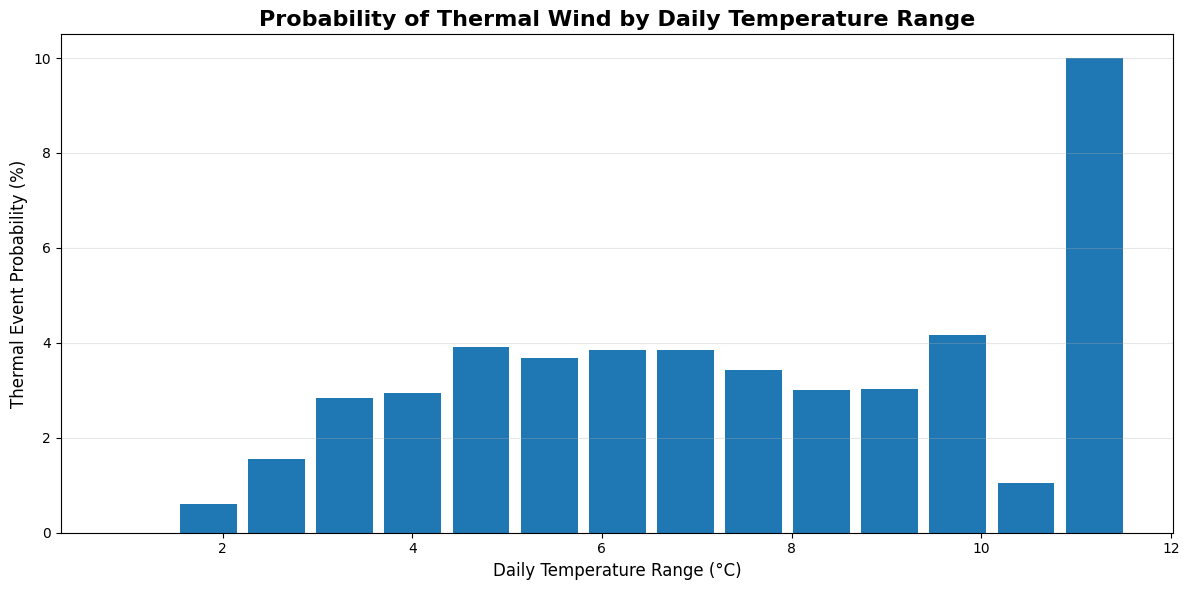

In [328]:
# =========================================================
# BAR CHART VERSION
# =========================================================

plt.figure(figsize=(12,6))

plt.bar(
    bin_centers,
    daily_range_prob.values,
    width=0.6
)

plt.title(
    'Probability of Thermal Wind by Daily Temperature Range',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Daily Temperature Range (°C)',
    fontsize=12
)

plt.ylabel(
    'Thermal Event Probability (%)',
    fontsize=12
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [329]:
daily_range_count = (
    df.groupby('daily_range_bin', observed=False)
      .size()
)

display(
    pd.DataFrame({
        'thermal_probability': daily_range_prob,
        'count': daily_range_count
    })
)

,thermal_probability,count
daily_range_bin,,
"(0.764, 1.493]",0.000000,624
"(1.493, 2.212]",0.605413,2808
"(2.212, 2.93]",1.550388,6192
"(2.93, 3.648]",2.833333,13800
"(3.648, 4.367]",2.941176,20400
"(4.367, 5.085]",3.905460,23736
"(5.085, 5.803]",3.675964,23232
"(5.803, 6.522]",3.844414,17688
"(6.522, 7.24]",3.839590,14064


In [330]:
corr_cols = [

    'thermal_event',

    'wind_avg',

    'land_sea_temp_gradient',

    'solar_gradient_interaction',

    'sst_air_diff',

    'air_temp_combined',

    'sst',

    'daily_temp_range',

    'Irradiància solar global',

    'Humitat relativa',

    'Pressió atmosfèrica'

]

spearman_corr = (
    df[corr_cols]
    .corr(method='spearman')
)

spearman_corr

,thermal_event,wind_avg,land_sea_temp_gradient,solar_gradient_interaction,sst_air_diff,air_temp_combined,sst,daily_temp_range,Irradiància solar global,Humitat relativa,Pressió atmosfèrica
thermal_event,1.000000,0.399521,0.189134,0.160095,0.189134,0.144766,0.071583,0.026133,0.143598,-0.066911,-0.058904
wind_avg,0.399521,1.000000,0.253494,0.225592,0.253494,0.179394,0.069121,-0.070167,-0.035659,0.014441,-0.170599
land_sea_temp_gradient,0.189134,0.253494,1.000000,0.557079,1.000000,0.603820,0.156338,-0.277183,0.379149,-0.032231,-0.121053
solar_gradient_interaction,0.160095,0.225592,0.557079,1.000000,0.557079,0.281373,0.056226,-0.137015,0.048571,0.072093,-0.065334
sst_air_diff,0.189134,0.253494,1.000000,0.557079,1.000000,0.603820,0.156338,-0.277183,0.379149,-0.032231,-0.121053
air_temp_combined,0.144766,0.179394,0.603820,0.281373,0.603820,1.000000,0.859376,-0.299232,0.299869,0.080612,-0.137985
sst,0.071583,0.069121,0.156338,0.056226,0.156338,0.859376,1.000000,-0.187588,0.151953,0.119032,-0.094452
daily_temp_range,0.026133,-0.070167,-0.277183,-0.137015,-0.277183,-0.299232,-0.187588,1.000000,-0.017965,-0.349235,0.157851
Irradiància solar global,0.143598,-0.035659,0.379149,0.048571,0.379149,0.299869,0.151953,-0.017965,1.000000,-0.201400,-0.022971
Humitat relativa,-0.066911,0.014441,-0.032231,0.072093,-0.032231,0.080612,0.119032,-0.349235,-0.201400,1.000000,-0.028763


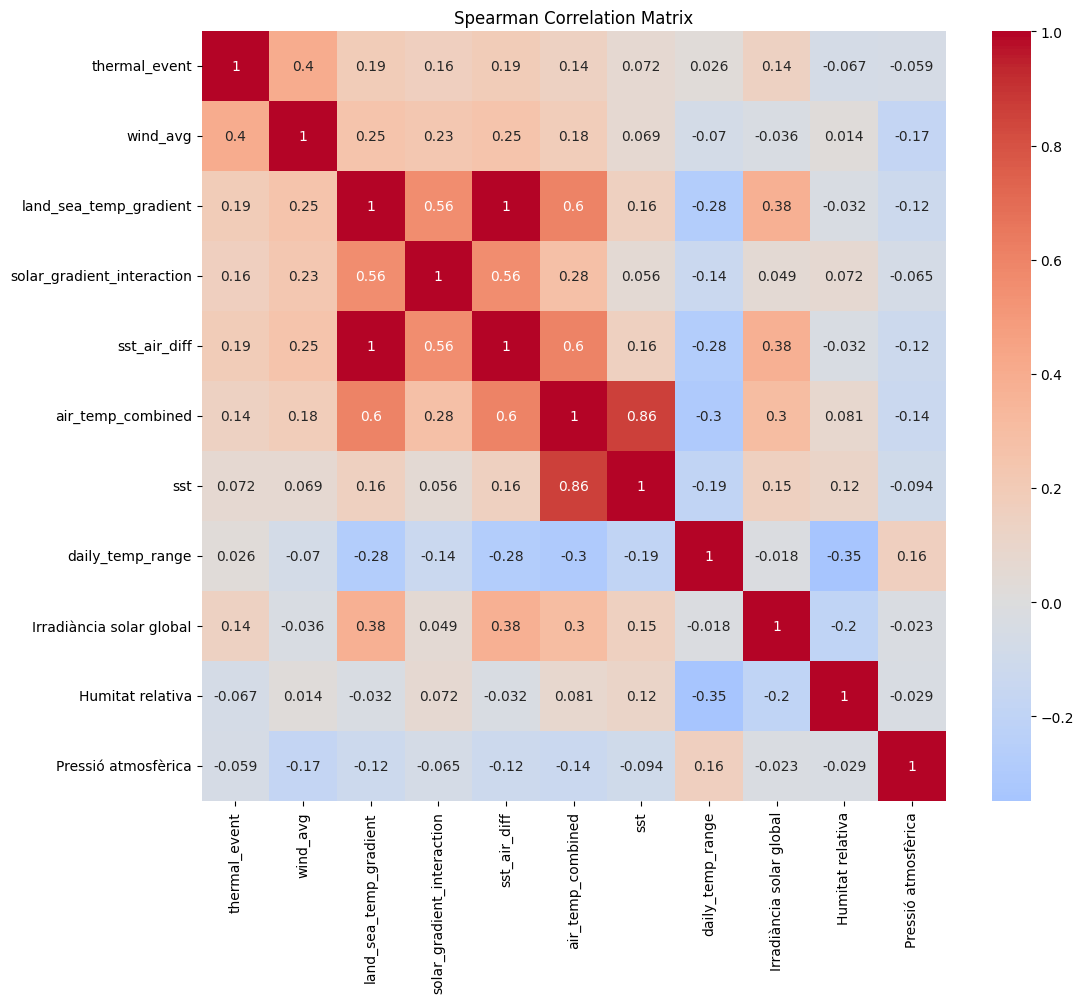

In [331]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title(
    'Spearman Correlation Matrix'
)

plt.show()

=========================================================

9. FINAL FEATURE SELECTION

=========================================================

In [332]:
# =========================================================
# REMOVE REDUNDANT FEATURES
# =========================================================

drop_cols = [

    # Redundant with land_sea_temp_gradient
    'sst_air_diff',

    # Temporary analysis bins
    'gradient_bin',
    'irradiance_bin',
    'sst_bin'

]

# Drop only existing columns

drop_cols = [
    col for col in drop_cols
    if col in df.columns
]

df = df.drop(
    columns=drop_cols
)

print("Dropped columns:")
print(drop_cols)

print()
print("Dataset shape:")
print(df.shape)

Dropped columns:
['sst_air_diff', 'gradient_bin', 'irradiance_bin', 'sst_bin']

Dataset shape:
(140256, 63)


In [333]:
df.drop(columns=['unknown'], inplace=True)

### Revisión final de columnas

In [334]:
# =========================================================
# FINAL COLUMN REVIEW
# =========================================================

print("Total columns:")
print(len(df.columns))

print()
print(df.columns.tolist())

Total columns:
62

['Temperatura', 'Temperatura màxima', 'Temperatura mínima', 'Humitat relativa', 'Humitat relativa màxima', 'Humitat relativa mínima', 'Pressió atmosfèrica', 'Pressió atmosfèrica mínima', 'Velocitat del vent a 6 m (esc.)', 'Ratxa màxima del vent a 6 m', 'Precipitació', 'Precipitació màxima en 1 minut', 'Irradiància solar global', 'wind_u', 'wind_v', 'sst', 'sst_original', 'wave_height', 'wave_height_h13', 'wave_period_mean', 'wave_period_tm02', 'wave_peak_period', 'wave_max_period', 'wave_direction', 'wave_peak_direction', 'wave_angular_spread', 'sst_roll_6h', 'sst_roll_24h', 'sst_delta_3h', 'sst_delta_24h', 'temperature', 'wind_direction_deg', 'wind_avg', 'wind_min', 'wind_max', 'month', 'hour', 'is_operational_hour', 'wind_data_available', 'valid_wind_observation', 'operational_gap', 'day_of_year', 'season', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'pressure_tendency_3h', 'pressure_tendency_6h', 'air_temp_combined', 'coastal_inland_temp_diff', 'land_sea_temp_gr

### Comprobación de valores nulos

In [335]:
# =========================================================
# MISSING VALUES CHECK
# =========================================================

missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

print(missing.head(20))

coastal_inland_temp_diff      67401
wind_direction_deg            67309
wind_min                      67309
temperature                   67309
wind_avg                      67309
wind_max                      67309
wave_peak_direction           11527
wave_angular_spread           11527
wave_max_period               10770
wave_direction                 4643
wave_period_tm02               4156
wave_height                    3886
wave_period_mean               3886
wave_peak_period               3886
wave_height_h13                3886
sst_original                   3596
sst_delta_24h                  1138
sst_roll_24h                   1132
solar_gradient_interaction     1063
land_sea_temp_gradient         1063
dtype: int64


### Resumen dataset final

In [336]:
# =========================================================
# FINAL DATASET SUMMARY
# =========================================================

print("Shape:")
print(df.shape)

print()

print("Datetime range:")
print(df.index.min())
print(df.index.max())

print()

print("Total features:")
print(df.shape[1])

Shape:
(140256, 62)

Datetime range:
2010-01-01 00:00:00
2025-12-31 23:00:00

Total features:
62


### Variables candidatas para ML v1

In [337]:
# =========================================================
# ML FEATURE CANDIDATES
# =========================================================

feature_candidates = [

    # Time

    'hour',
    'month',
    'season',

    'hour_sin',
    'hour_cos',

    'doy_sin',
    'doy_cos',

    # Thermal

    'land_sea_temp_gradient',

    'air_temp_combined',

    'daily_temp_range',

    'sst',

    # Radiation

    'Irradiància solar global',

    'solar_roll_3h',
    'solar_roll_6h',

    # Atmospheric

    'Humitat relativa',

    'Pressió atmosfèrica',

    # Interaction

    'solar_gradient_interaction'

]

print(feature_candidates)

['hour', 'month', 'season', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'land_sea_temp_gradient', 'air_temp_combined', 'daily_temp_range', 'sst', 'Irradiància solar global', 'solar_roll_3h', 'solar_roll_6h', 'Humitat relativa', 'Pressió atmosfèrica', 'solar_gradient_interaction']


=========================================================

10. EXPORT FEATURED DATASET

=========================================================

In [338]:
# =========================================================
# EXPORT FEATURED DATASET
# =========================================================

output_path = (
    '../data/gold/featured_dataset_v1.parquet'
)

df.to_parquet(
    output_path,
    index=True
)

print("FEATURED DATASET EXPORTED")
print("-" * 50)

print(f"Path: {output_path}")

print()

print("Shape:")
print(df.shape)

print()

print("Datetime range:")
print(df.index.min())
print(df.index.max())

print()

print("Total columns:")
print(len(df.columns))

ArrowNotImplementedError: Unsupported cast from dictionary<values=extension<pandas.interval<ArrowIntervalType>>, indices=int8, ordered=1> to struct using function cast_struct

In [ ]:
df.shape

df.info()

df[['thermal_event',
    'sailable_wind']].describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 140256 entries, 2010-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 61 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Temperatura                      140063 non-null  float32
 1   Temperatura màxima               140072 non-null  float32
 2   Temperatura mínima               140073 non-null  float32
 3   Humitat relativa                 140099 non-null  float32
 4   Humitat relativa màxima          140103 non-null  float32
 5   Humitat relativa mínima          140099 non-null  float32
 6   Pressió atmosfèrica              140113 non-null  float32
 7   Pressió atmosfèrica mínima       140113 non-null  float32
 8   Velocitat del vent a 6 m (esc.)  140148 non-null  float32
 9   Ratxa màxima del vent a 6 m      140148 non-null  float32
 10  Precipitació                     140256 non-null  float32
 11  Precipitació màxima en 1 minut   140145 no

,thermal_event,sailable_wind
count,140256.000000,140256.000000
mean,0.033432,0.075426
std,0.179762,0.264079
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


In [ ]:
df

,Temperatura,Temperatura màxima,Temperatura mínima,Humitat relativa,Humitat relativa màxima,Humitat relativa mínima,Pressió atmosfèrica,Pressió atmosfèrica mínima,Velocitat del vent a 6 m (esc.),Ratxa màxima del vent a 6 m,Precipitació,Precipitació màxima en 1 minut,Irradiància solar global,wind_u,wind_v,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,month,hour,is_operational_hour,wind_data_available,valid_wind_observation,operational_gap,day_of_year,season,hour_sin,hour_cos,doy_sin,doy_cos,pressure_tendency_3h,pressure_tendency_6h,air_temp_combined,coastal_inland_temp_diff,land_sea_temp_gradient,thermal_wind_flag,thermal_event,sailable_wind,daily_temp_range,solar_roll_3h,solar_roll_6h,sst_climatology,sst_anomaly,solar_gradient_interaction
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,11.80,12.1,11.3,48.0,49.0,46.0,989.500000,989.000000,7.40,16.900000,0.2,0.2,0.0,-1.852812,-7.164292,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,1,1,0.000000,1.000000,1.721336e-02,0.999852,NaN,NaN,11.80,NaN,-2.20,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 01:00:00,10.90,11.3,10.3,49.0,51.0,47.0,990.000000,989.000000,7.80,17.200001,0.0,0.0,0.0,-0.611981,-7.775955,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,1,1,0.258819,0.965926,1.721336e-02,0.999852,NaN,NaN,10.90,NaN,-3.10,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 02:00:00,10.30,10.3,10.2,49.5,51.0,48.0,990.000000,989.000000,7.95,15.900000,0.0,0.0,0.0,-0.208105,-7.947276,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,0,0,0,0,1,1,0.500000,0.866025,1.721336e-02,0.999852,NaN,NaN,10.30,NaN,-3.70,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
2010-01-01 03:00:00,9.85,10.2,9.6,47.0,48.0,47.0,990.500000,990.000000,8.00,16.299999,0.0,0.0,0.0,-0.627673,-7.975338,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,3,0,0,0,0,1,1,0.707107,0.707107,1.721336e-02,0.999852,1.000000,NaN,9.85,NaN,-4.15,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
2010-01-01 04:00:00,9.50,9.6,9.4,46.0,47.0,45.0,991.000000,990.000000,7.15,15.900000,0.0,0.0,0.0,-1.241584,-7.041375,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,4,0,0,0,0,1,1,0.866025,0.500000,1.721336e-02,0.999852,1.000000,NaN,9.50,NaN,-4.50,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,8.90,9.4,8.5,73.5,74.0,73.0,1016.549988,1016.400024,3.40,6.700000,0.0,0.0,0.0,1.826819,-2.867531,14.4,14.4,1.39,1.31,4.70,4.80,6.40,NaN,81.0,NaN,NaN,14.433333,14.450000,0.0,-0.1,11.0,150.0,0.0,0.0,2.0,12,19,1,1,1,0,365,1,-0.965926,0.258819,6.432491e-16,1.000000,1.049988,2.000000,9.95,-2.1,-4.45,False,0,0,3.700000,0.0,76.000000,15.471736,-1.071736,-0.0
2025-12-31 20:00:00,8.00,8.5,7.8,76.0,77.0,74.0,1016.800049,1016.599976,3.80,6.000000,0.0,0.0,0.0,2.467902,-2.889543,14.4,14.4,1.32,1.25,4.50,4.60,6.10,NaN,78.0,NaN,NaN,14.416667,14.445833,0.0,-0.1,NaN,NaN,NaN,NaN,NaN,12,20,0,0,0,0,365,1,-0.866025,0.500000,6.432491e-16,1.000000,0.950073,1.900024,8.00,NaN,-6.40,False,0,0,3.700000,0.0,16.666667,15.469653,-1.069653,-0.0
2025-12-31 21:00:00,7.85,8.1,7.7,75.0,76.0,74.0,1017.099976,1017.000000,3.55,6.900000,0.0,0.0,0.0,2.658793,-2.352301,14.4,14.4,1.27,1.23,4.80,4.60,5.80,NaN,69.0,NaN,NaN,14.400000,14.441667,0.0,-0.1,NaN,NaN,NaN,NaN,NaN,12,21,0,0,0,0,365,1,-0.707107,0.707107,6.432491e-16,1.000000,0.849976,1.

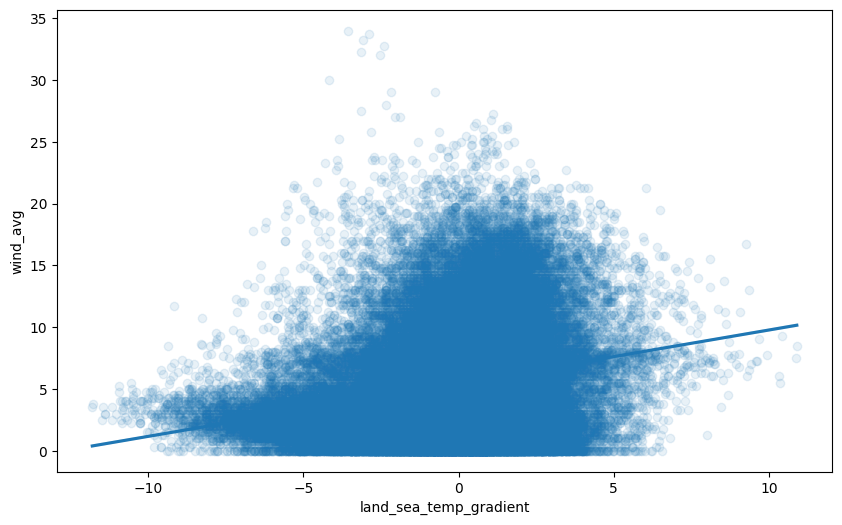

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='land_sea_temp_gradient',
    y='wind_avg',
    scatter_kws={'alpha':0.1}
)

plt.show()